In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn import metrics
from sklearn.model_selection import train_test_split
url = "https://docs.google.com/spreadsheets/d/1qAUshUDemSGgR1zuHfMpawlOhqk2aCIS/export?format=csv&gid=1531156511"

df = pd.read_csv(url)
df.head()

,Index,AdmissionDate,DischargeDate,30DayReadmissionFlag,DaysBetweenDCAndReadmission,MDCCategory,Sex,EnglishPrimaryLanguageFlag,Race Category,AgeGroup,...,Food Insecurity,Health Literacy,Housing Stability,Intimate Partner Violence,Physical Activity,Social Connections,Stress,Tobacco Use,Transportation Needs,Utilities
0,1,12/26/2024,1/3/2025,0,NaN,PN,Female,1,White,80+,...,0,0,1,0,1,0,0,0,0,0
1,2,11/29/2024,12/5/2024,0,109.0,HF,Male,1,NonWhite,60-69,...,0,0,1,0,0,0,0,0,0,0
2,3,6/13/2025,6/15/2025,0,NaN,AMI,Female,1,White,60-69,...,0,0,0,0,1,1,0,1,0,0
3,4,5/16/2025,5/20/2025,0,63.0,AMI,Female,1,White,60-69,...,0,0,0,0,1,0,0,1,0,0
4,5,11/27/2024,12/5/2024,0,NaN,CABG,Male,1,White,70-79,...,0,0,0,0,1,1,0,0,0,0


In [7]:
#Identify how many rows have 30DayReadmissionFlag Error and which ones
ReadmissionFlagError = df[(df['30DayReadmissionFlag'] == 0) & (df['DaysBetweenDCAndReadmission'] <= 30)]
print("Total errors in Readmission Flag:", len(ReadmissionFlagError))
print(ReadmissionFlagError["Index"])

Total errors in Readmission Flag: 44
9         10
36        37
392      393
492      493
544      545
550      551
671      672
964      965
1003    1004
1136    1137
1240    1241
1675    1676
2024    2025
2038    2039
2111    2112
2292    2293
2312    2313
2466    2467
2530    2531
2636    2637
2694    2695
2827    2828
3109    3110
3152    3153
3326    3327
3607    3608
3631    3632
3660    3661
3865    3866
4010    4011
4019    4020
4210    4211
4295    4296
4388    4389
4402    4403
4576    4577
4592    4593
4763    4764
4797    4798
4849    4850
4855    4856
5024    5025
5230    5231
5282    5283
Name: Index, dtype: int64


In [8]:
#Used numpy tool to replace 30DayReadmissionFlag values where error occurs
df["30DayReadmissionFlag"] = np.where(
    (df['30DayReadmissionFlag'] == 0) & (df['DaysBetweenDCAndReadmission'] <= 30),
    1,
    df['30DayReadmissionFlag']
)
ReadmissionFlagError = df[(df['30DayReadmissionFlag'] == 0) & (df['DaysBetweenDCAndReadmission'] <= 30)]
print("Total errors in Readmission Flag:", len(ReadmissionFlagError))

Total errors in Readmission Flag: 0


In [9]:
#Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

missing_percentage = (df.isnull().sum() / len(df)) * 100
print("Missing percentage per column:")
print(missing_percentage)

Missing values per column:
Index                             0
AdmissionDate                     0
DischargeDate                     0
30DayReadmissionFlag              0
DaysBetweenDCAndReadmission    3215
MDCCategory                       0
Sex                               0
EnglishPrimaryLanguageFlag        0
Race Category                     0
AgeGroup                          0
SexualOrientation                 0
MaritalStatus                     0
SmokingStatus                     0
AnchorStayMedsPriorToDC           0
AnchorStayTOCConsult              0
DCLoungeFlag                      0
ReadmissionRiskValue             19
ReadmissionRiskCategory          19
NextEDVisitDate                3020
AdmittedFromED                 3020
MDCReasonForVisit              3020
NextStayRelatedToAnchor        3020
30Days_EDVisits                   0
60Days_EDVisits                   0
90Days_EDVisits                   0
30Days_Hospitalizations           0
60Days_Hospitalizations           0
9

In [10]:
#Since ReadmissionRiskValue and ReadmissionRiskCategory have low missing value amounts, we check which rows have these missing values
RiskValueMissing = df[df['ReadmissionRiskValue'].isnull()]
RiskCategoryMissing = df[df['ReadmissionRiskCategory'].isnull()]
print("Rows with ReadmissionRiskValue missing:",RiskValueMissing[['Index','ReadmissionRiskValue']])
print("Rows with ReadmissionRiskCategory missing:",RiskCategoryMissing[['Index','ReadmissionRiskCategory']])

Rows with ReadmissionRiskValue missing:       Index  ReadmissionRiskValue
25       26                   NaN
175     176                   NaN
334     335                   NaN
565     566                   NaN
639     640                   NaN
940     941                   NaN
1110   1111                   NaN
1181   1182                   NaN
1359   1360                   NaN
1470   1471                   NaN
1592   1593                   NaN
1658   1659                   NaN
1792   1793                   NaN
2524   2525                   NaN
2530   2531                   NaN
2636   2637                   NaN
2954   2955                   NaN
4425   4426                   NaN
5240   5241                   NaN
Rows with ReadmissionRiskCategory missing:       Index ReadmissionRiskCategory
25       26                     NaN
175     176                     NaN
334     335                     NaN
565     566                     NaN
639     640                     NaN
940     941          

In [11]:
#Check for 30DayReadmissionFlag with value 1 but Days Between DC and Readmission null
ReadmissionFlagNULLError = df[(df['30DayReadmissionFlag'] == 1) & (df['DaysBetweenDCAndReadmission'].isnull())]
print("Total null errors in Readmission Flag:", len(ReadmissionFlagNULLError))
print(ReadmissionFlagNULLError["Index"])

Total null errors in Readmission Flag: 0
Series([], Name: Index, dtype: int64)


In [12]:
#Check for any errors where Discharge Date is before Admission Date
DischargeBeforeAdmission = df[df['DischargeDate'] < df['AdmissionDate']]
print("Total errors in DischargeDate:", len(DischargeBeforeAdmission))
print(DischargeBeforeAdmission["Index"])
DischargeBeforeAdmission.head()

Total errors in DischargeDate: 1033
0          1
6          7
8          9
13        14
18        19
        ... 
5246    5247
5270    5271
5271    5272
5278    5279
5280    5281
Name: Index, Length: 1033, dtype: int64


,Index,AdmissionDate,DischargeDate,30DayReadmissionFlag,DaysBetweenDCAndReadmission,MDCCategory,Sex,EnglishPrimaryLanguageFlag,Race Category,AgeGroup,...,Food Insecurity,Health Literacy,Housing Stability,Intimate Partner Violence,Physical Activity,Social Connections,Stress,Tobacco Use,Transportation Needs,Utilities
0,1,12/26/2024,1/3/2025,0,NaN,PN,Female,1,White,80+,...,0,0,1,0,1,0,0,0,0,0
6,7,9/3/2025,9/16/2025,0,NaN,CABG,Male,1,White,70-79,...,0,0,0,0,0,0,0,1,0,0
8,9,9/6/2024,9/13/2024,0,57.0,HF,Female,1,White,80+,...,0,0,0,0,1,0,0,1,0,0
13,14,6/8/2025,6/16/2025,0,NaN,Stroke,Female,1,White,80+,...,0,0,0,0,0,0,0,0,0,0
18,19,12/2/2025,12/16/2025,0,NaN,Sepsis,Female,1,White,60-69,...,0,0,1,0,1,0,1,0,1,1


In [13]:
#30DayReadmissionFlag percentages, post 30DayReadmissionFlag Fix
ReadmissionFlag = (df['30DayReadmissionFlag'].value_counts()/ len(df))*100
print("30DayReadmissionFlag percentages:")
print(ReadmissionFlag)

30DayReadmissionFlag percentages:
30DayReadmissionFlag
0    84.85536
1    15.14464
Name: count, dtype: float64


In [14]:
#Separate dataset into two datasets: 30DayReadmissionFlag 1 and 30DayReadmissionFlag 0
ReadmissionFlag1 = df[df['30DayReadmissionFlag'] == 1]
ReadmissionFlag0 = df[df['30DayReadmissionFlag'] == 0]
print(ReadmissionFlag1[ReadmissionFlag1.columns[:4]].head())
print(ReadmissionFlag0[ReadmissionFlag0.columns[:4]].head())

    Index AdmissionDate DischargeDate  30DayReadmissionFlag
5       6     6/11/2024     6/13/2024                     1
9      10     6/28/2024      7/9/2024                     1
10     11     11/4/2024     11/8/2024                     1
17     18      8/1/2025      8/6/2025                     1
22     23    10/29/2025     11/5/2025                     1
   Index AdmissionDate DischargeDate  30DayReadmissionFlag
0      1    12/26/2024      1/3/2025                     0
1      2    11/29/2024     12/5/2024                     0
2      3     6/13/2025     6/15/2025                     0
3      4     5/16/2025     5/20/2025                     0
4      5    11/27/2024     12/5/2024                     0


In [15]:
# Create the days between TCM Visit and Discharge Date
df["TCMVisitDate"] = pd.to_datetime(df["TCMVisitDate"], errors="coerce")
df["DischargeDate"] = pd.to_datetime(df["DischargeDate"], errors="coerce")
df["DaysBetweenTCMDischarge"] = (df["TCMVisitDate"] - df["DischargeDate"]).dt.days

# See the unique dates to determine the dates
df["DaysBetweenTCMDischarge"].unique()


array([nan,  4.,  9., 14.,  1.,  3.,  6.,  5.,  7., 10.,  8.,  2., 11.,
       12., 13., 15.])

In [16]:
df.head(10)

,Index,AdmissionDate,DischargeDate,30DayReadmissionFlag,DaysBetweenDCAndReadmission,MDCCategory,Sex,EnglishPrimaryLanguageFlag,Race Category,AgeGroup,...,Health Literacy,Housing Stability,Intimate Partner Violence,Physical Activity,Social Connections,Stress,Tobacco Use,Transportation Needs,Utilities,DaysBetweenTCMDischarge
0,1,12/26/2024,2025-01-03,0,NaN,PN,Female,1,White,80+,...,0,1,0,1,0,0,0,0,0,NaN
1,2,11/29/2024,2024-12-05,0,109.0,HF,Male,1,NonWhite,60-69,...,0,1,0,0,0,0,0,0,0,NaN
2,3,6/13/2025,2025-06-15,0,NaN,AMI,Female,1,White,60-69,...,0,0,0,1,1,0,1,0,0,NaN
3,4,5/16/2025,2025-05-20,0,63.0,AMI,Female,1,White,60-69,...,0,0,0,1,0,0,1,0,0,NaN
4,5,11/27/2024,2024-12-05,0,NaN,CABG,Male,1,White,70-79,...,0,0,0,1,1,0,0,0,0,NaN
5,6,6/11/2024,2024-06-13,1,19.0,Stroke,Male,1,White,80+,...,1,0,0,1,0,1,1,1,0,4.0
6,7,9/3/2025,2025-09-16,0,NaN,CABG,Male,1,White,70-79,...,0,0,0,0,0,0,1,0,0,NaN
7,8,5/27/2025,2025-06-09,0,NaN,Sepsis,Male,1,White,80+,...,0,0,0,1,1,0,1,0,0,9.0
8,9,9/6/2024,2024-09-13,0,57.0,HF,Female,1,White,80+,...,0,0,0,1,0,0,1,0,0,NaN
9,10,6/28/2024,2024-07-09,1,7.0,Sepsis,Male,1,White,70-79,...,0,0,0,1,0,1,1,1,0,NaN


In [17]:
# Encode AgeGroup as an ordered numerical factor
age_mapping = {
    '18-39': 1,
    '40-49': 2,
    '50-59': 3,
    '60-69': 4,
    '70-79': 5,
    '80+': 6
}
df['AgeGroup'] = df['AgeGroup'].map(age_mapping)

# One-Hot Encoding to MDCCategory
df = pd.get_dummies(df, columns=['MDCCategory'], prefix='MDC')

# Verify the transformations
print("First 5 rows of transformed AgeGroup and One-Hot columns:")
cols_to_preview = ['AgeGroup'] + [col for col in df.columns if col.startswith('MDC_')]
print(df[cols_to_preview].head())

First 5 rows of transformed AgeGroup and One-Hot columns:
   AgeGroup  MDC_AMI  MDC_CABG  MDC_COPD  MDC_HF  MDC_HipKnee  MDC_PN  \
0         6    False     False     False   False        False    True   
1         4    False     False     False    True        False   False   
2         4     True     False     False   False        False   False   
3         4     True     False     False   False        False   False   
4         5    False      True     False   False        False   False   

   MDC_Sepsis  MDC_Stroke  
0       False       False  
1       False       False  
2       False       False  
3       False       False  
4       False       False  


In [18]:
# Convert dates to datetime objects
df['DischargeDate'] = pd.to_datetime(df['DischargeDate'])
df['TCMVisitDate'] = pd.to_datetime(df['TCMVisitDate'])

# Calculate days between Discharge and TCM Visit
df['DaysToTCM'] = (df['TCMVisitDate'] - df['DischargeDate']).dt.days

# Create TCM flags (1 if visit within window, 0 otherwise)
df['TCM_7d'] = np.where((df['DaysToTCM'] >= 0) & (df['DaysToTCM'] <= 7), 1, 0)
df['TCM_10d'] = np.where((df['DaysToTCM'] >= 0) & (df['DaysToTCM'] <= 10), 1, 0)
df['TCM_14d'] = np.where((df['DaysToTCM'] >= 0) & (df['DaysToTCM'] <= 14), 1, 0)

# Create Composite Bundle Scores (0 to 3)
df['TOC_bundle_7d'] = df['AnchorStayMedsPriorToDC'] + df['AnchorStayTOCConsult'] + df['TCM_7d']
df['TOC_bundle_10d'] = df['AnchorStayMedsPriorToDC'] + df['AnchorStayTOCConsult'] + df['TCM_10d']
df['TOC_bundle_14d'] = df['AnchorStayMedsPriorToDC'] + df['AnchorStayTOCConsult'] + df['TCM_14d']

In [19]:
# Readmission Censoring Rule
# DaysBetweenDCAndReadmission is 'censored' at 30 days if no readmission occurs
# or if the readmission happens after the 30-day window.
df['SurvivalTime'] = np.where(
    df['30DayReadmissionFlag'] == 1,
    df['DaysBetweenDCAndReadmission'],
    30
)
# Fill cases where there was no readmission at all (NaN) with 30
df['SurvivalTime'] = df['SurvivalTime'].fillna(30).clip(upper=30)

# TCM Missingness Rules
# Main Model: Blank TCMVisitDate = "No TCM recorded" (Value 0)
# (This was handled during the creation of the TOC_bundle/TCM_7d flags)
#df['TCM_main'] = df['TCM_7d']

# Sensitivity Analysis: Identify cases to exclude (e.g., Early Failures)
# We flag patients readmitted within 48 hours who never received TCM,
# as they did not have a clinical 'window' to receive the bundle.
df['Sensitivity_Sample'] = 1
df.loc[(df['30DayReadmissionFlag'] == 1) &
       (df['DaysBetweenDCAndReadmission'] < 3) &
       (df['TCM_7d'] == 0), 'Sensitivity_Sample'] = 0

In [20]:
df.head()

,Index,AdmissionDate,DischargeDate,30DayReadmissionFlag,DaysBetweenDCAndReadmission,Sex,EnglishPrimaryLanguageFlag,Race Category,AgeGroup,SexualOrientation,...,MDC_Stroke,DaysToTCM,TCM_7d,TCM_10d,TCM_14d,TOC_bundle_7d,TOC_bundle_10d,TOC_bundle_14d,SurvivalTime,Sensitivity_Sample
0,1,12/26/2024,2025-01-03,0,NaN,Female,1,White,6,Straight,...,False,NaN,0,0,0,1,1,1,30.0,1
1,2,11/29/2024,2024-12-05,0,109.0,Male,1,NonWhite,4,Straight,...,False,NaN,0,0,0,2,2,2,30.0,1
2,3,6/13/2025,2025-06-15,0,NaN,Female,1,White,4,Straight,...,False,NaN,0,0,0,1,1,1,30.0,1
3,4,5/16/2025,2025-05-20,0,63.0,Female,1,White,4,*Unspecified,...,False,NaN,0,0,0,2,2,2,30.0,1
4,5,11/27/2024,2024-12-05,0,NaN,Male,1,White,5,Straight,...,False,NaN,0,0,0,2,2,2,30.0,1


# **Part 2: Descriptive and Balance Diagnostics**

## **a. General Readmission Rate**

In [21]:
#What percent of Readmissions had each MDC
ReadmissionFlag1 = df[df['30DayReadmissionFlag'] == 1]

AMI_Readmissions = ReadmissionFlag1[ReadmissionFlag1['MDC_AMI'] == True]
AMI_Readmission_Percent = round(len(AMI_Readmissions)/len(ReadmissionFlag1),4)

CABG_Readmissions = ReadmissionFlag1[ReadmissionFlag1['MDC_CABG'] == True]
CABG_Readmission_Percent = round(len(CABG_Readmissions)/len(ReadmissionFlag1),4)

COPD_Readmissions = ReadmissionFlag1[ReadmissionFlag1['MDC_COPD'] == True]
COPD_Readmission_Percent = round(len(COPD_Readmissions)/len(ReadmissionFlag1),4)

HF_Readmissions = ReadmissionFlag1[ReadmissionFlag1['MDC_HF'] == True]
HF_Readmission_Percent = round(len(HF_Readmissions)/len(ReadmissionFlag1),4)

HipKnee_Readmissions = ReadmissionFlag1[ReadmissionFlag1['MDC_HipKnee'] == True]
HipKnee_Readmission_Percent = round(len(HipKnee_Readmissions)/len(ReadmissionFlag1),4)

PN_Readmissions = ReadmissionFlag1[ReadmissionFlag1['MDC_PN'] == True]
PN_Readmission_Percent = round(len(PN_Readmissions)/len(ReadmissionFlag1),4)

Sepsis_Readmissions = ReadmissionFlag1[ReadmissionFlag1['MDC_Sepsis'] == True]
Sepsis_Readmission_Percent = round(len(Sepsis_Readmissions)/len(ReadmissionFlag1),4)

Stroke_Readmissions = ReadmissionFlag1[ReadmissionFlag1['MDC_Stroke'] == True]
Stroke_Readmission_Percent = round(len(Stroke_Readmissions)/len(ReadmissionFlag1),4)

print(AMI_Readmission_Percent*100,"% of Readmissions had AMI")
print(CABG_Readmission_Percent*100,"% of Readmissions had CABG")
print(COPD_Readmission_Percent*100,"% of Readmissions had COPD")
print(HF_Readmission_Percent*100,"% of Readmissions had HF")
print(HipKnee_Readmission_Percent*100,"% of Readmissions had HipKnee")
print(PN_Readmission_Percent*100,"% of Readmissions had PN")
print(Sepsis_Readmission_Percent*100,"% of Readmissions had Sepsis")
print(Stroke_Readmission_Percent*100,"% of Readmissions had Stroke")

5.87 % of Readmissions had AMI
3.1199999999999997 % of Readmissions had CABG
13.23 % of Readmissions had COPD
23.599999999999998 % of Readmissions had HF
1.7500000000000002 % of Readmissions had HipKnee
15.110000000000001 % of Readmissions had PN
27.72 % of Readmissions had Sepsis
9.610000000000001 % of Readmissions had Stroke


In [22]:
#What percent of each MDC was readmitted

AMI_Patients = df[df['MDC_AMI'] == True]
AMI_Patient_Readmissions = AMI_Patients[AMI_Patients['30DayReadmissionFlag'] == 1]
AMI_Readmission_Rate = round(len(AMI_Patient_Readmissions)/len(AMI_Patients),4)

CABG_Patients = df[df['MDC_CABG'] == True]
CABG_Patient_Readmissions = CABG_Patients[CABG_Patients['30DayReadmissionFlag'] == 1]
CABG_Readmission_Rate = round(len(CABG_Patient_Readmissions)/len(CABG_Patients),4)

COPD_Patients = df[df['MDC_COPD'] == True]
COPD_Patient_Readmissions = COPD_Patients[COPD_Patients['30DayReadmissionFlag'] == 1]
COPD_Readmission_Rate = round(len(COPD_Patient_Readmissions)/len(COPD_Patients),4)

HF_Patients = df[df['MDC_HF'] == True]
HF_Patient_Readmissions = HF_Patients[HF_Patients['30DayReadmissionFlag'] == 1]
HF_Readmission_Rate = round(len(HF_Patient_Readmissions)/len(HF_Patients),4)

HipKnee_Patients = df[df['MDC_HipKnee'] == True]
HipKnee_Patient_Readmissions = HipKnee_Patients[HipKnee_Patients['30DayReadmissionFlag'] == 1]
HipKnee_Readmission_Rate = round(len(HipKnee_Patient_Readmissions)/len(HipKnee_Patients),4)

PN_Patients = df[df['MDC_PN'] == True]
PN_Patient_Readmissions = PN_Patients[PN_Patients['30DayReadmissionFlag'] == 1]
PN_Readmission_Rate = round(len(PN_Patient_Readmissions)/len(PN_Patients),4)

Sepsis_Patients = df[df['MDC_Sepsis'] == True]
Sepsis_Patient_Readmissions = Sepsis_Patients[Sepsis_Patients['30DayReadmissionFlag'] == 1]
Sepsis_Readmission_Rate = round(len(Sepsis_Patient_Readmissions)/len(Sepsis_Patients),4)

Stroke_Patients = df[df['MDC_Stroke'] == True]
Stroke_Patient_Readmissions = Stroke_Patients[Stroke_Patients['30DayReadmissionFlag'] == 1]
Stroke_Readmission_Rate = round(len(Stroke_Patient_Readmissions)/len(Stroke_Patients),4)

print(AMI_Readmission_Rate*100,"% of AMI patients were readmitted")
print(CABG_Readmission_Rate*100,"% of CABG patients were readmitted")
print(COPD_Readmission_Rate*100,"% of COPD patients were readmitted")
print(HF_Readmission_Rate*100,"% of HF patients were readmitted")
print(HipKnee_Readmission_Rate*100,"% of HipKnee patients were readmitted")
print(PN_Readmission_Rate*100,"% of PN patients were readmitted")
print(Sepsis_Readmission_Rate*100,"% of Sepsis patients were readmitted")
print(Stroke_Readmission_Rate*100,"% of Stroke patients were readmitted")

7.7 % of AMI patients were readmitted
10.33 % of CABG patients were readmitted
24.54 % of COPD patients were readmitted
21.02 % of HF patients were readmitted
12.280000000000001 % of HipKnee patients were readmitted
19.8 % of PN patients were readmitted
14.75 % of Sepsis patients were readmitted
8.790000000000001 % of Stroke patients were readmitted


In [23]:
#What percent of Readmissions were which risk level

from re import M

High_Risk_Readmissions = ReadmissionFlag1[ReadmissionFlag1['ReadmissionRiskCategory'] == 'High']
High_Risk_Readmission_Percent = round(len(High_Risk_Readmissions)/len(ReadmissionFlag1),4)

Medium_Risk_Readmissions = ReadmissionFlag1[ReadmissionFlag1['ReadmissionRiskCategory'] == 'Medium']
Medium_Risk_Readmission_Percent = round(len(Medium_Risk_Readmissions)/len(ReadmissionFlag1),4)

Low_Risk_Readmissions = ReadmissionFlag1[ReadmissionFlag1['ReadmissionRiskCategory'] == 'Low']
Low_Risk_Readmission_Percent = round(len(Low_Risk_Readmissions)/len(ReadmissionFlag1),4)

print(High_Risk_Readmission_Percent*100,"% of Readmissions were High Risk")
print(Medium_Risk_Readmission_Percent*100,"% of Readmissions were Medium Risk")
print(Low_Risk_Readmission_Percent*100,"% of Readmissions were Low Risk")

43.82 % of Readmissions were High Risk
35.709999999999994 % of Readmissions were Medium Risk
20.22 % of Readmissions were Low Risk


In [24]:
#What percent of each risk level was readmitted

HighRisk_Patients = df[df['ReadmissionRiskCategory'] == 'High']
HighRisk_Patient_Readmissions = HighRisk_Patients[HighRisk_Patients['30DayReadmissionFlag'] == 1]
HighRisk_Readmission_Rate = round(len(HighRisk_Patient_Readmissions)/len(HighRisk_Patients),4)

MediumRisk_Patients = df[df['ReadmissionRiskCategory'] == 'Medium']
MediumRisk_Patient_Readmissions = MediumRisk_Patients[MediumRisk_Patients['30DayReadmissionFlag'] == 1]
MediumRisk_Readmission_Rate = round(len(MediumRisk_Patient_Readmissions)/len(MediumRisk_Patients),4)

LowRisk_Patients = df[df['ReadmissionRiskCategory'] == 'Low']
LowRisk_Patient_Readmissions = LowRisk_Patients[LowRisk_Patients['30DayReadmissionFlag'] == 1]
LowRisk_Readmission_Rate = round(len(LowRisk_Patient_Readmissions)/len(LowRisk_Patients),4)

print(HighRisk_Readmission_Rate*100,"% of High Risk patients were readmitted")
print(MediumRisk_Readmission_Rate*100,"% of Medium Risk patients were readmitted")
print(LowRisk_Readmission_Rate*100,"% of Low Risk patients were readmitted")

19.009999999999998 % of High Risk patients were readmitted
16.39 % of Medium Risk patients were readmitted
9.65 % of Low Risk patients were readmitted


In [25]:
#Readmission breakdown by age

_18to39_Readmissions = ReadmissionFlag1[(ReadmissionFlag1['AgeGroup'] == 1)]
_18to39_Readmission_Percent = round(len(_18to39_Readmissions)/len(ReadmissionFlag1),4)

_40to49_Readmissions = ReadmissionFlag1[(ReadmissionFlag1['AgeGroup'] == 2 )]
_40to49_Readmission_Percent = round(len(_40to49_Readmissions)/len(ReadmissionFlag1),4)

_50to59_Readmissions = ReadmissionFlag1[(ReadmissionFlag1['AgeGroup'] == 3)]
_50to59_Readmission_Percent = round(len(_50to59_Readmissions)/len(ReadmissionFlag1),4)

_60to69_Readmissions = ReadmissionFlag1[(ReadmissionFlag1['AgeGroup'] == 4)]
_60to69_Readmission_Percent = round(len(_60to69_Readmissions)/len(ReadmissionFlag1),4)

_70to79_Readmissions = ReadmissionFlag1[(ReadmissionFlag1['AgeGroup'] == 5)]
_70to79_Readmission_Percent = round(len(_70to79_Readmissions)/len(ReadmissionFlag1),4)

_80Plus_Readmissions = ReadmissionFlag1[(ReadmissionFlag1['AgeGroup'] == 6)]
_80Plus_Readmission_Percent = round(len(_80Plus_Readmissions)/len(ReadmissionFlag1),4)

print(_18to39_Readmission_Percent*100,"% of Readmissions were 18-39")
print(_40to49_Readmission_Percent*100,"% of Readmissions were 40-49")
print(_50to59_Readmission_Percent*100,"% of Readmissions were 50-59")
print(_60to69_Readmission_Percent*100,"% of Readmissions were 60-69")
print(_70to79_Readmission_Percent*100,"% of Readmissions were 70-79")
print(_80Plus_Readmission_Percent*100,"% of Readmissions were 80+")

2.0 % of Readmissions were 18-39
3.8699999999999997 % of Readmissions were 40-49
7.99 % of Readmissions were 50-59
23.72 % of Readmissions were 60-69
29.21 % of Readmissions were 70-79
33.21 % of Readmissions were 80+


In [26]:
#What percent of each age group was readmitted

_18to39_Patients = df[df['AgeGroup'] == 1]
_18to39_Patient_Readmissions = _18to39_Patients[_18to39_Patients['30DayReadmissionFlag'] == 1]
_18to39_Readmission_Rate = round(len(_18to39_Patient_Readmissions)/len(_18to39_Patients),4)

_40to49_Patients = df[df['AgeGroup'] == 2]
_40to49_Patient_Readmissions = _40to49_Patients[_40to49_Patients['30DayReadmissionFlag'] == 1]
_40to49_Readmission_Rate = round(len(_40to49_Patient_Readmissions)/len(_40to49_Patients),4)

_50to59_Patients = df[df['AgeGroup'] == 3]
_50to59_Patient_Readmissions = _50to59_Patients[_50to59_Patients['30DayReadmissionFlag'] == 1]
_50to59_Readmission_Rate = round(len(_50to59_Patient_Readmissions)/len(_50to59_Patients),4)

_60to69_Patients = df[df['AgeGroup'] == 4]
_60to69_Patient_Readmissions = _60to69_Patients[_60to69_Patients['30DayReadmissionFlag'] == 1]
_60to69_Readmission_Rate = round(len(_60to69_Patient_Readmissions)/len(_60to69_Patients),4)

_70to79_Patients = df[df['AgeGroup'] == 5]
_70to79_Patient_Readmissions = _70to79_Patients[_70to79_Patients['30DayReadmissionFlag'] == 1]
_70to79_Readmission_Rate = round(len(_70to79_Patient_Readmissions)/len(_70to79_Patients),4)

_80Plus_Patients = df[df['AgeGroup'] == 6]
_80Plus_Patient_Readmissions = _80Plus_Patients[_80Plus_Patients['30DayReadmissionFlag'] == 1]
_80Plus_Readmission_Rate = round(len(_80Plus_Patient_Readmissions)/len(_80Plus_Patients),4)

print(_18to39_Readmission_Rate*100,"% of patients age 18-39 were readmitted")
print(_40to49_Readmission_Rate*100,"% of patients age 40-49 were readmitted")
print(_50to59_Readmission_Rate*100,"% of patients age 50-59 were readmitted")
print(_60to69_Readmission_Rate*100,"% of patients age 60-69 were readmitted")
print(_70to79_Readmission_Rate*100,"% of patients age 70-79 were readmitted")
print(_80Plus_Readmission_Rate*100,"% of patients age 80+ were readmitted")

7.2700000000000005 % of patients age 18-39 were readmitted
10.51 % of patients age 40-49 were readmitted
12.19 % of patients age 50-59 were readmitted
15.939999999999998 % of patients age 60-69 were readmitted
16.259999999999998 % of patients age 70-79 were readmitted
16.439999999999998 % of patients age 80+ were readmitted


In [27]:
#Readmission breakdown by SDOH

Alc_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Alcohol Use']==1]
Alc_Readmission_Percent = round(len(Alc_Readmissions)/len(ReadmissionFlag1),4)

Depression_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Depression']==1]
Depression_Readmission_Percent = round(len(Depression_Readmissions)/len(ReadmissionFlag1),4)

Financial_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Financial Resource Strain']==1]
Financial_Readmission_Percent = round(len(Financial_Readmissions)/len(ReadmissionFlag1),4)

FoodInsecurity_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Food Insecurity']==1]
FoodInsecurity_Readmission_Percent = round(len(FoodInsecurity_Readmissions)/len(ReadmissionFlag1),4)

HealthLiteracy_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Health Literacy']==1]
HealthLiteracy_Readmission_Percent = round(len(HealthLiteracy_Readmissions)/len(ReadmissionFlag1),4)

Housing_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Housing Stability']==1]
Housing_Readmission_Percent = round(len(Housing_Readmissions)/len(ReadmissionFlag1),4)

Violence_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Intimate Partner Violence']==1]
Violence_Readmission_Percent = round(len(Violence_Readmissions)/len(ReadmissionFlag1),4)

PhysActivity_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Physical Activity']==1]
PhysActivity_Readmission_Percent = round(len(PhysActivity_Readmissions)/len(ReadmissionFlag1),4)

Social_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Social Connections']==1]
Social_Readmission_Percent = round(len(Social_Readmissions)/len(ReadmissionFlag1),4)

Stress_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Stress']==1]
Stress_Readmission_Percent = round(len(Stress_Readmissions)/len(ReadmissionFlag1),4)

Tobacco_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Tobacco Use']==1]
Tobacco_Readmission_Percent = round(len(Tobacco_Readmissions)/len(ReadmissionFlag1),4)

Transportation_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Transportation Needs']==1]
Transportation_Readmission_Percent = round(len(Transportation_Readmissions)/len(ReadmissionFlag1),4)

Utilities_Readmissions = ReadmissionFlag1[ReadmissionFlag1['Utilities']==1]
Utilities_Readmission_Percent = round(len(Utilities_Readmissions)/len(ReadmissionFlag1),4)

print(Alc_Readmission_Percent*100,"% of readmitted patients reported alcohol use")
print(Depression_Readmission_Percent*100,"% of readmitted patients reported being depressed")
print(Financial_Readmission_Percent*100,"% of readmitted patients reported financial resource strain")
print(FoodInsecurity_Readmission_Percent*100,"% of readmitted patients reported food insecurity")
print(HealthLiteracy_Readmission_Percent*100,"% of readmitted patients reported struggling with health literacy")
print(Housing_Readmission_Percent*100,"% of readmitted patients reported housing instability")
print(Violence_Readmission_Percent*100,"% of readmitted patients reported experiencing intimate partner violence")
print(PhysActivity_Readmission_Percent*100,"% of readmitted patients reported low physical activity")
print(Social_Readmission_Percent*100,"% of readmitted patients reported experiencing social isolation")
print(Stress_Readmission_Percent*100,"% of readmitted patients reported experiencing stress or anxiety")
print(Tobacco_Readmission_Percent*100,"% of readmitted patients reported tobacco use")
print(Transportation_Readmission_Percent*100,"% of readmitted patients reported experiencing transportation barriers")
print(Utilities_Readmission_Percent*100,"% of readmitted patients reported financial challenges in paying for utilities")

10.74 % of readmitted patients reported alcohol use
17.849999999999998 % of readmitted patients reported being depressed
29.09 % of readmitted patients reported financial resource strain
17.98 % of readmitted patients reported food insecurity
7.62 % of readmitted patients reported struggling with health literacy
19.1 % of readmitted patients reported housing instability
1.7500000000000002 % of readmitted patients reported experiencing intimate partner violence
88.51 % of readmitted patients reported low physical activity
73.16 % of readmitted patients reported experiencing social isolation
42.57 % of readmitted patients reported experiencing stress or anxiety
70.66 % of readmitted patients reported tobacco use
25.840000000000003 % of readmitted patients reported experiencing transportation barriers
8.110000000000001 % of readmitted patients reported financial challenges in paying for utilities


In [28]:
#What percent of each SDOH was readmitted

AlcUse_Patients = df[df['Alcohol Use'] == 1]
AlcUse_Patient_Readmissions = AlcUse_Patients[AlcUse_Patients['30DayReadmissionFlag'] == 1]
AlcUse_Readmission_Rate = round(len(AlcUse_Patient_Readmissions)/len(AlcUse_Patients),4)

Depression_Patients = df[df['Depression'] == 1]
Depression_Patient_Readmissions = Depression_Patients[Depression_Patients['30DayReadmissionFlag'] == 1]
Depression_Readmission_Rate = round(len(Depression_Patient_Readmissions)/len(Depression_Patients),4)

FinStrain_Patients = df[df['Financial Resource Strain'] == 1]
FinStrain_Patient_Readmissions = FinStrain_Patients[FinStrain_Patients['30DayReadmissionFlag'] == 1]
FinStrain_Readmission_Rate = round(len(FinStrain_Patient_Readmissions)/len(FinStrain_Patients),4)

FoodInsecurity_Patients = df[df['Food Insecurity'] == 1]
FoodInsecurity_Patient_Readmissions = FoodInsecurity_Patients[FoodInsecurity_Patients['30DayReadmissionFlag'] == 1]
FoodInsecurity_Readmission_Rate = round(len(FoodInsecurity_Patient_Readmissions)/len(FoodInsecurity_Patients),4)

HealthLiteracy_Patients = df[df['Health Literacy'] == 1]
HealthLiteracy_Patient_Readmissions = HealthLiteracy_Patients[HealthLiteracy_Patients['30DayReadmissionFlag'] == 1]
HealthLiteracy_Readmission_Rate = round(len(HealthLiteracy_Patient_Readmissions)/len(HealthLiteracy_Patients),4)

Housing_Patients = df[df['Housing Stability'] == 1]
Housing_Patient_Readmissions = Housing_Patients[Housing_Patients['30DayReadmissionFlag'] == 1]
Housing_Readmission_Rate = round(len(Housing_Patient_Readmissions)/len(Housing_Patients),4)

PartnerViolence_Patients = df[df['Intimate Partner Violence'] == 1]
PartnerViolence_Patients_Readmissions = PartnerViolence_Patients[PartnerViolence_Patients['30DayReadmissionFlag'] == 1]
PartnerViolence_Readmission_Rate = round(len(PartnerViolence_Patients_Readmissions)/len(PartnerViolence_Patients),4)

PhysicalActivity_Patients = df[df['Physical Activity'] == 1]
PhysicalActivity_Patient_Readmissions = PhysicalActivity_Patients[PhysicalActivity_Patients['30DayReadmissionFlag'] == 1]
PhysicalActivity_Readmission_Rate = round(len(PhysicalActivity_Patient_Readmissions)/len(PhysicalActivity_Patients),4)

SocialConnections_Patients = df[df['Social Connections'] == 1]
SocialConnections_Patient_Readmissions = SocialConnections_Patients[SocialConnections_Patients['30DayReadmissionFlag'] == 1]
SocialConnections_Readmission_Rate = round(len(SocialConnections_Patient_Readmissions)/len(SocialConnections_Patients),4)

Stress_Patients = df[df['Stress'] == 1]
Stress_Patient_Readmissions = Stress_Patients[Stress_Patients['30DayReadmissionFlag'] == 1]
Stress_Readmission_Rate = round(len(Stress_Patient_Readmissions)/len(Stress_Patients),4)

Tobacco_Patients = df[df['Tobacco Use'] == 1]
Tobacco_Patient_Readmissions = Tobacco_Patients[Tobacco_Patients['30DayReadmissionFlag'] == 1]
Tobacco_Readmission_Rate = round(len(Tobacco_Patient_Readmissions)/len(Tobacco_Patients),4)

Transportation_Patients = df[df['Transportation Needs'] == 1]
Transportation_Patient_Readmissions = Transportation_Patients[Transportation_Patients['30DayReadmissionFlag'] == 1]
Transportation_Readmission_Rate = round(len(Transportation_Patient_Readmissions)/len(Transportation_Patients),4)

Utilities_Patients = df[df['Utilities'] == 1]
Utilities_Patient_Readmissions = Utilities_Patients[Utilities_Patients['30DayReadmissionFlag'] == 1]
Utilities_Readmission_Rate = round(len(Utilities_Patient_Readmissions)/len(Utilities_Patients),4)

print(AlcUse_Readmission_Rate*100,"% of patients that reported alcohol use were readmitted")
print(Depression_Readmission_Rate*100,"% of patients that reported being depressed were readmitted")
print(FinStrain_Readmission_Rate*100,"% of patients that reported fincancial strain were readmitted")
print(FoodInsecurity_Readmission_Rate*100,"% of patients that reported food insecurity were readmitted")
print(HealthLiteracy_Readmission_Rate*100,"% of patients that reported struggling with health literacy were readmitted")
print(Housing_Readmission_Rate*100,"% of patients that reported housing instability were readmitted")
print(PartnerViolence_Readmission_Rate*100,"% of patients that reported intimate partner violence were readmitted")
print(PhysicalActivity_Readmission_Rate*100,"% of patients that reported low physical activity were readmitted")
print(SocialConnections_Readmission_Rate*100,"% of patients that reported social isolation were readmitted")
print(Stress_Readmission_Rate*100,"% of patients that reported stress or anxiety were readmitted")
print(Tobacco_Readmission_Rate*100,"% of patients that reported tobacco use were readmitted")
print(Transportation_Readmission_Rate*100,"% of patients that reported transportation barriers were readmitted")
print(Utilities_Readmission_Rate*100,"% of patients that reported financial challenges in paying for utilities were readmitted")

14.63 % of patients that reported alcohol use were readmitted
18.5 % of patients that reported being depressed were readmitted
22.49 % of patients that reported fincancial strain were readmitted
24.740000000000002 % of patients that reported food insecurity were readmitted
20.13 % of patients that reported struggling with health literacy were readmitted
23.72 % of patients that reported housing instability were readmitted
18.42 % of patients that reported intimate partner violence were readmitted
18.37 % of patients that reported low physical activity were readmitted
19.78 % of patients that reported social isolation were readmitted
24.060000000000002 % of patients that reported stress or anxiety were readmitted
16.04 % of patients that reported tobacco use were readmitted
25.590000000000003 % of patients that reported transportation barriers were readmitted
25.1 % of patients that reported financial challenges in paying for utilities were readmitted


## **b. Treatment Prevalence**

In [29]:
#Since 1 seems to be extremely prevalent in AnchorStayMedsPriorToDC, check to see if any patients have 0
Meds_Distinct = df['AnchorStayMedsPriorToDC'].unique()
print(Meds_Distinct)

[1 0]


In [30]:
#Find out how many didn't receive meds prior to DC
No_Meds = df[df['AnchorStayMedsPriorToDC'] == 0]
print(len(No_Meds))
No_Meds.head()

35


,Index,AdmissionDate,DischargeDate,30DayReadmissionFlag,DaysBetweenDCAndReadmission,Sex,EnglishPrimaryLanguageFlag,Race Category,AgeGroup,SexualOrientation,...,MDC_Stroke,DaysToTCM,TCM_7d,TCM_10d,TCM_14d,TOC_bundle_7d,TOC_bundle_10d,TOC_bundle_14d,SurvivalTime,Sensitivity_Sample
69,70,5/5/2025,2025-05-09,1,3.0,Female,1,White,4,Straight,...,False,NaN,0,0,0,0,0,0,3.0,1
195,196,6/10/2025,2025-06-13,0,NaN,Female,1,White,6,Choose not to disclose,...,False,NaN,0,0,0,0,0,0,30.0,1
238,239,9/6/2025,2025-09-11,0,120.0,Female,1,White,5,*Unspecified,...,False,12.0,0,0,1,1,1,2,30.0,1
367,368,4/25/2025,2025-05-09,0,NaN,Male,1,White,5,Straight,...,False,NaN,0,0,0,0,0,0,30.0,1
400,401,9/2/2024,2024-09-09,0,NaN,Female,1,White,6,Straight,...,False,NaN,0,0,0,0,0,0,30.0,1


In [31]:
#Given small amount of no meds entries, we go straight into readmission rates among 1 and 0 instead of checking Readmission breakdown by meds
No_Meds_Readmissions = No_Meds[No_Meds['30DayReadmissionFlag'] == 1]
No_Meds_Readmission_Rate = round(len(No_Meds_Readmissions)/len(No_Meds),4)

Meds = df[df['AnchorStayMedsPriorToDC'] == 1]
Meds_Readmissions = Meds[Meds['30DayReadmissionFlag'] == 1]
Meds_Readmission_Rate = round(len(Meds_Readmissions)/len(Meds),4)

Overall_Readmission_Rate = round(len(ReadmissionFlag1)/len(df),4)

print("Overall,",Overall_Readmission_Rate*100,"% of patients were readmitted")
print(No_Meds_Readmission_Rate*100,"% of patients without meds prior to DC were readmitted")
print(Meds_Readmission_Rate*100,"% of patients with meds prior to DC were readmitted")

Overall, 15.14 % of patients were readmitted
8.57 % of patients without meds prior to DC were readmitted
15.190000000000001 % of patients with meds prior to DC were readmitted


In [32]:
No_Meds_Consult_Distinct = No_Meds['AnchorStayTOCConsult'].unique()
print(No_Meds_Consult_Distinct)
#print(No_Meds['AnchorStayTOCConsult'])
NoMeds_Consult_Split = (No_Meds['AnchorStayTOCConsult'].value_counts()/ len(No_Meds))*100
print(NoMeds_Consult_Split)

[0 1]
AnchorStayTOCConsult
0    62.857143
1    37.142857
Name: count, dtype: float64


In [33]:
#What percent of Readmissions received a consult
Consult_Readmissions = ReadmissionFlag1[ReadmissionFlag1['AnchorStayTOCConsult'] == 1]
Consult_Readmission_Percent = round(len(Consult_Readmissions)/len(ReadmissionFlag1),4)

NoConsult_Readmissions = ReadmissionFlag1[ReadmissionFlag1['AnchorStayTOCConsult'] == 0]
NoConsult_Readmission_Percent = round(len(NoConsult_Readmissions)/len(ReadmissionFlag1),4)

print(Consult_Readmission_Percent*100,"% of Readmissions received a pharmacy consult prior to discharge")
print(NoConsult_Readmission_Percent*100,"% of Readmissions did not receive a pharmacy consult prior to discharge")

24.09 % of Readmissions received a pharmacy consult prior to discharge
75.91 % of Readmissions did not receive a pharmacy consult prior to discharge


In [34]:
#What % of Consult/No Consult were readmitted
Consult_Patients = df[df['AnchorStayTOCConsult'] == 1]
Consult_Patient_Readmissions = Consult_Patients[Consult_Patients['30DayReadmissionFlag'] == 1]
Consult_Readmission_Rate = round(len(Consult_Patient_Readmissions)/len(Consult_Patients),4)

NoConsult_Patients = df[df['AnchorStayTOCConsult'] == 0]
NoConsult_Patient_Readmissions = NoConsult_Patients[NoConsult_Patients['30DayReadmissionFlag'] == 1]
NoConsult_Readmission_Rate = round(len(NoConsult_Patient_Readmissions)/len(NoConsult_Patients),4)

print(Consult_Readmission_Rate*100,"% of patients that received a consult were readmitted")
print(NoConsult_Readmission_Rate*100,"% of patients that did not receive a consult were readmitted")

11.95 % of patients that received a consult were readmitted
16.55 % of patients that did not receive a consult were readmitted


In [35]:
TCM_Chart = df[["TCM_7d","TCM_10d","TCM_14d"]]
TCM_Chart.head()

,TCM_7d,TCM_10d,TCM_14d
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [36]:
#Readmission Breakdown by TCM date range
TCM_7d_Readmissions = ReadmissionFlag1[ReadmissionFlag1['TCM_7d'] == 1]
TCM_7d_Readmission_Percent = round(len(TCM_7d_Readmissions)/len(ReadmissionFlag1),4)

TCM_10d_Readmissions = ReadmissionFlag1[ReadmissionFlag1['TCM_10d'] == 1]
TCM_10d_Readmission_Percent = round(len(TCM_10d_Readmissions)/len(ReadmissionFlag1),4)

TCM_14d_Readmissions = ReadmissionFlag1[ReadmissionFlag1['TCM_14d'] == 1]
TCM_14d_Readmission_Percent = round(len(TCM_14d_Readmissions)/len(ReadmissionFlag1),4)

print(TCM_7d_Readmission_Percent*100,"% of Readmissions received a TCM within 7 days")
print(TCM_10d_Readmission_Percent*100,"% of Readmissions received a TCM within 10 days")
print(TCM_14d_Readmission_Percent*100,"% of Readmissions received a TCM within 14 days")

6.12 % of Readmissions received a TCM within 7 days
9.11 % of Readmissions received a TCM within 10 days
12.73 % of Readmissions received a TCM within 14 days


In [37]:
#What percent of each TCM date range was readmitted
TCM_7d_Patients = df[df['TCM_7d'] == 1]
TCM_7d_Patient_Readmissions = TCM_7d_Patients[TCM_7d_Patients['30DayReadmissionFlag'] == 1]
TCM_7d_Readmission_Rate = round(len(TCM_7d_Patient_Readmissions)/len(TCM_7d_Patients),4)

TCM_10d_Patients = df[df['TCM_10d'] == 1]
TCM_10d_Patient_Readmissions = TCM_10d_Patients[TCM_10d_Patients['30DayReadmissionFlag'] == 1]
TCM_10d_Readmission_Rate = round(len(TCM_10d_Patient_Readmissions)/len(TCM_10d_Patients),4)

TCM_14d_Patients = df[df['TCM_14d'] == 1]
TCM_14d_Patient_Readmissions = TCM_14d_Patients[TCM_14d_Patients['30DayReadmissionFlag'] == 1]
TCM_14d_Readmission_Rate = round(len(TCM_14d_Patient_Readmissions)/len(TCM_14d_Patients),4)

print(TCM_7d_Readmission_Rate*100,"% of patients that received a TCM within 7 days were readmitted")
print(TCM_10d_Readmission_Rate*100,"% of patients that received a TCM within 10 days were readmitted")
print(TCM_14d_Readmission_Rate*100,"% of patients that received a TCM within 14 days were readmitted")

8.49 % of patients that received a TCM within 7 days were readmitted
8.63 % of patients that received a TCM within 10 days were readmitted
9.29 % of patients that received a TCM within 14 days were readmitted


## **c. "Balance" Checks**

### **i. Risk Score and SDOH comparison between Treated and Untreated patients**

In [38]:
#I want to create a way to measure SDOH per patient
#Note: Could probably use different SDOH features that were engineered below, see "SDOH Feature Engineering"
df['SDOH Score'] = df[
    [
        'Alcohol Use','Depression','Financial Resource Strain','Food Insecurity','Health Literacy','Housing Stability','Intimate Partner Violence','Physical Activity',
        'Social Connections','Stress','Tobacco Use','Transportation Needs','Utilities'
    ]
].sum(axis = 1)

#Let's separate treated vs untreated patients
Treated = df[(df['AnchorStayMedsPriorToDC'] == 1) | (df['AnchorStayTOCConsult'] == 1) | (df['TCM_7d'] == 1) | (df['TCM_10d'] == 1) | (df['TCM_14d'] == 1)]
UnTreated = df[(df['AnchorStayMedsPriorToDC'] == 0) & (df['AnchorStayTOCConsult'] == 0) & (df['TCM_7d'] == 0) & (df['TCM_10d'] == 0) & (df['TCM_14d'] == 0)]

#Determine Average Risk and SDOH scores between treated and untreated patients
Treated_Avg_Risk = round(Treated['ReadmissionRiskValue'].mean(),2)
Treated_Avg_SDOH = round(Treated['SDOH Score'].mean(),2)

Untreated_Avg_Risk = round(UnTreated['ReadmissionRiskValue'].mean(),2)
Untreated_Avg_SDOH = round(UnTreated['SDOH Score'].mean(),2)

print("Treated Patients","\nAverage Risk Value:",Treated_Avg_Risk,"\nAverage SDOH:",Treated_Avg_SDOH)
print("\nUntreated Patients","\nAverage Risk Value:",Untreated_Avg_Risk,"\nAverage SDOH:",Untreated_Avg_SDOH)

Treated Patients 
Average Risk Value: 17.93 
Average SDOH: 3.18

Untreated Patients 
Average Risk Value: 19.64 
Average SDOH: 3.67


### **ii. Standardise mean difference pre and post-weighting**

In [39]:
import math
#SMD for Risk Value
TreatedRiskMean = Treated['ReadmissionRiskValue'].mean()
UntreatedRiskMean = UnTreated['ReadmissionRiskValue'].mean()

TreatedRiskVar = Treated['ReadmissionRiskValue'].var()
UntreatedRiskVar = UnTreated['ReadmissionRiskValue'].var()

Risk_PooledSD = math.sqrt((TreatedRiskVar + UntreatedRiskVar)/2)

RiskSMD = abs(round((TreatedRiskMean - UntreatedRiskMean)/Risk_PooledSD,2))

#SMD for SDOH Score
TreatedSDOHMean = Treated['SDOH Score'].mean()
UntreatedSDOHMean = UnTreated['SDOH Score'].mean()

TreatedSDOHVar = Treated['SDOH Score'].var()
UntreatedSDOHVar = UnTreated['SDOH Score'].var()

SDOH_PooledSD = math.sqrt((TreatedSDOHVar + UntreatedSDOHVar)/2)

SDOHSMD = abs(round((TreatedSDOHMean - UntreatedSDOHMean)/SDOH_PooledSD,2))

print("Standardized Mean Difference (pre-weighting)","\nRisk Value:",RiskSMD,"\nSDOH:",SDOHSMD)

Standardized Mean Difference (pre-weighting) 
Risk Value: 0.15 
SDOH: 0.2


In [40]:
#Add a Treatment Indicator so we can differentiate between both groups in one data frame, making it easier to determine propensity score and weight
df["Treatment Indicator"] = 0
df.loc[df['Index'].isin(Treated['Index']), "Treatment Indicator"] = 1

from sklearn.linear_model import LogisticRegression

#Determine propensity scores
X = df[["ReadmissionRiskValue","SDOH Score"]]
y = df["Treatment Indicator"]

X = X.fillna(X.median())
model = LogisticRegression()
model.fit(X, y)

df["propensity_score"] = model.predict_proba(X)[:,1]

#Determine weights using propensity score
df["weight"] = (
    df["Treatment Indicator"] / df["propensity_score"] +
    (1 - df["Treatment Indicator"]) / (1 - df["propensity_score"])
)

#Make function for weighted variance
def weighted_var(x, w):
    mean = np.average(x, weights=w)
    return np.average((x - mean)**2, weights=w)

#Reintroduce Treated and UnTreated with new features
Treated = df[(df['AnchorStayMedsPriorToDC'] == 1) | (df['AnchorStayTOCConsult'] == 1) | (df['TCM_7d'] == 1) | (df['TCM_10d'] == 1) | (df['TCM_14d'] == 1)]
UnTreated = df[(df['AnchorStayMedsPriorToDC'] == 0) & (df['AnchorStayTOCConsult'] == 0) & (df['TCM_7d'] == 0) & (df['TCM_10d'] == 0) & (df['TCM_14d'] == 0)]

#Get rid of nan in ReadmissionRiskValue for both Treated and UnTreated
Treated_clean = Treated.dropna(subset=['ReadmissionRiskValue'])
UnTreated_clean = UnTreated.dropna(subset=['ReadmissionRiskValue'])

#Weighted SMD for Risk Value
#Weighted Mean
WeightedTreatedRiskMean = np.average(Treated_clean['ReadmissionRiskValue'], weights=Treated_clean['weight'])
WeightedUntreatedRiskMean = np.average(UnTreated_clean['ReadmissionRiskValue'], weights=UnTreated_clean['weight'])

#Weighted Variance
WeightedTreatedRiskVar = weighted_var(Treated_clean['ReadmissionRiskValue'], Treated_clean['weight'])
WeightedUntreatedRiskVar = weighted_var(UnTreated_clean['ReadmissionRiskValue'], UnTreated_clean['weight'])

WeightedRisk_PooledSD = math.sqrt((WeightedTreatedRiskVar + WeightedUntreatedRiskVar)/2)

WeightedRiskSMD = abs(round((WeightedTreatedRiskMean - WeightedUntreatedRiskMean)/WeightedRisk_PooledSD,2))

#Weighted SMD for SDOH Score
WeightedTreatedSDOHMean = np.average(Treated['SDOH Score'], weights=Treated['weight'])
WeightedUntreatedSDOHMean = np.average(UnTreated['SDOH Score'], weights=UnTreated['weight'])

WeightedTreatedSDOHVar = weighted_var(Treated['SDOH Score'], Treated['weight'])
WeightedUntreatedSDOHVar = weighted_var(UnTreated['SDOH Score'], UnTreated['weight'])

WeightedSDOH_PooledSD = math.sqrt((WeightedTreatedSDOHVar + WeightedUntreatedSDOHVar)/2)

WeightedSDOHSMD =abs(round((WeightedTreatedSDOHMean - WeightedUntreatedSDOHMean)/WeightedSDOH_PooledSD,3))

print("Standardized Mean Difference (post-weighting)","\nRisk Value:",WeightedRiskSMD,"\nSDOH:",WeightedSDOHSMD)

Standardized Mean Difference (post-weighting) 
Risk Value: 0.05 
SDOH: 0.004


## **SDOH Feature Engineering**

In [41]:
#First, Normalize SDOH Score
df['SDOH Score z'] = (df['SDOH Score'] - df['SDOH Score'].mean())/df['SDOH Score'].std()

#Now Create Domain Specific Scores
#Domain groupings are as follows:
behavior = ["Alcohol Use","Physical Activity","Tobacco Use"]
mental = ["Depression","Stress","Social Connections","Intimate Partner Violence"]
financial = ["Financial Resource Strain","Utilities","Food Insecurity","Housing Stability"]
access = ["Health Literacy","Transportation Needs"]

#Now create scores
df['behavior score'] = df[behavior].sum(axis = 1)
df['mental score'] = df[mental].sum(axis = 1)
df['financial score'] = df[financial].sum(axis = 1)
df['access score'] = df[access].sum(axis = 1)

#Normalize domain scores
df['behavior score z'] = (df['behavior score'] - df['behavior score'].mean())/df['behavior score'].std()
df['mental score z'] = (df['mental score'] - df['mental score'].mean())/df['mental score'].std()
df['financial score z'] = (df['financial score'] - df['financial score'].mean())/df['financial score'].std()
df['access score z'] = (df['access score'] - df['access score'].mean())/df['access score'].std()

#Compute MCA scores
#Run the pip install code below when running for the first time
!pip install prince
import prince
SDOH_cols = [
        'Alcohol Use','Depression','Financial Resource Strain','Food Insecurity','Health Literacy','Housing Stability','Intimate Partner Violence','Physical Activity',
        'Social Connections','Stress','Tobacco Use','Transportation Needs','Utilities'
    ]
mca = prince.MCA(
    n_components=2,
    random_state=42
)

mca = mca.fit(df[SDOH_cols])

mca_components = mca.transform(df[SDOH_cols])

df["SDOH MCA Score"] = mca_components[0]

print(df[['SDOH Score'] + df.columns[-10:].tolist()].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.3/197.3 kB 5.2 MB/s eta 0:00:00
   SDOH Score  SDOH Score z  behavior score  mental score  financial score  \
0           2     -0.547038               1             0                1   
1           2     -0.547038               0             0                2   
2           4      0.377334               2             1                1   
3           2     -0.547038               2             0                0   
4           3     -0.084852               1             2                0   

   access score  behavior score z  mental score z  financial score z  \
0             0         -0.657624       -1.090556           0.570977   
1             0         -1.952069       -1.090556           1.662374   
2             0          0.636821        0.012725           0.570977   
3             0          0.636821       -1.090556          -0.520421   
4             0         -0.657624        1.116005          -0.520421   

   access score z 

## **More Feature Engineering**

###**Socioeconomic Vulnerability:**

In [42]:
df["SVI"] = (df['behavior score z'] + df['mental score z'] + df['financial score z'] + df['access score z'])/4

#Normalize for use with model
df['SVI_z'] = (df['SVI'] - df['SVI'].mean())/df['SVI'].std()

#Min max scaling, typical SVI Index representation
df['SVI_Index'] = (df['SVI'] - df['SVI'].min())/(df['SVI'].max() - df['SVI'].min())

X = sm.add_constant(df["SVI_z"])
y = df["30DayReadmissionFlag"]

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.409497
         Iterations 6
                            Logit Regression Results                            
Dep. Variable:     30DayReadmissionFlag   No. Observations:                 5289
Model:                            Logit   Df Residuals:                     5287
Method:                             MLE   Df Model:                            1
Date:                  Wed, 13 May 2026   Pseudo R-squ.:                 0.03695
Time:                          19:23:30   Log-Likelihood:                -2165.8
converged:                         True   LL-Null:                       -2248.9
Covariance Type:              nonrobust   LLR p-value:                 4.967e-38
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7978      0.041    -44.252      0.000      -1.877      -1.718
SVI_z        

### **Social Support/Isolation Index**

In [43]:
#I want to include marital status in calculation the isolation index along with other relevant SDOHs
df['Marital Isolation'] = df['MaritalStatus'].isin(['Single','Widowed','Divorced']).astype(int)

support_cols = ['Social Connections','Depression','Stress','Intimate Partner Violence','Marital Isolation']

df['Isolation Score'] = df[support_cols].sum(axis = 1)
df['Isolation Score z'] = (df['Isolation Score'] - df['Isolation Score'].mean())/df['Isolation Score'].std()

X = sm.add_constant(df["Isolation Score z"])
y = df["30DayReadmissionFlag"]

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.415834
         Iterations 6
                            Logit Regression Results                            
Dep. Variable:     30DayReadmissionFlag   No. Observations:                 5289
Model:                            Logit   Df Residuals:                     5287
Method:                             MLE   Df Model:                            1
Date:                  Wed, 13 May 2026   Pseudo R-squ.:                 0.02205
Time:                          19:23:30   Log-Likelihood:                -2199.3
converged:                         True   LL-Null:                       -2248.9
Covariance Type:              nonrobust   LLR p-value:                 2.303e-23
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.7723      0.040    -44.362      0.000      -1.851     

### **Compounded Vulnerabilities**

**SVI x Isolation**

In [44]:
df['SVI_iso'] = df['SVI_z'] * df['Isolation Score z']

X = df[["SVI_z","Isolation Score z","SVI_iso"]]
X = sm.add_constant(X)

y = df["30DayReadmissionFlag"]

model = sm.Logit(y, X).fit()
print(model.summary())
print("\nConclusion: Isolation is a key indicator in low SVI patients")

Optimization terminated successfully.
         Current function value: 0.407358
         Iterations 6
                            Logit Regression Results                            
Dep. Variable:     30DayReadmissionFlag   No. Observations:                 5289
Model:                            Logit   Df Residuals:                     5285
Method:                             MLE   Df Model:                            3
Date:                  Wed, 13 May 2026   Pseudo R-squ.:                 0.04198
Time:                          19:23:31   Log-Likelihood:                -2154.5
converged:                         True   LL-Null:                       -2248.9
Covariance Type:              nonrobust   LLR p-value:                 1.089e-40
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.7180      0.044    -38.719      0.000      -1.805     

**Isolation x Elderly**

In [45]:
#Identify patients age 70+
df['Elderly'] = ((df['AgeGroup'] == 5) | (df['AgeGroup'] == 6)).astype(int)

df['Elderly_iso'] = df['Isolation Score z'] * df['Elderly']

X = df[["Elderly","Isolation Score z","Elderly_iso"]]
X = sm.add_constant(X)

y = df["30DayReadmissionFlag"]

model = sm.Logit(y, X).fit()
print(model.summary())
print("\nConclusion: Isolation affects younger patients more than elderly patients")

Optimization terminated successfully.
         Current function value: 0.413253
         Iterations 6
                            Logit Regression Results                            
Dep. Variable:     30DayReadmissionFlag   No. Observations:                 5289
Model:                            Logit   Df Residuals:                     5285
Method:                             MLE   Df Model:                            3
Date:                  Wed, 13 May 2026   Pseudo R-squ.:                 0.02812
Time:                          19:23:31   Log-Likelihood:                -2185.7
converged:                         True   LL-Null:                       -2248.9
Covariance Type:              nonrobust   LLR p-value:                 3.094e-27
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.0528      0.072    -28.623      0.000      -2.193     

**Housing Instability x Substance use**

In [46]:
df['Substance Use'] = ((df['Tobacco Use'] == 1) | (df['Alcohol Use'] == 1)).astype(int)

df['Housing_Substance'] = df['Housing Stability'] * df['Substance Use']

X = df[["Housing Stability","Substance Use","Housing_Substance"]]
X = sm.add_constant(X)

y = df["30DayReadmissionFlag"]

model = sm.Logit(y, X).fit()
print(model.summary())
print("\nConclusion: No significant interaction between housing instability and substance use")

Optimization terminated successfully.
         Current function value: 0.421037
         Iterations 6
                            Logit Regression Results                            
Dep. Variable:     30DayReadmissionFlag   No. Observations:                 5289
Model:                            Logit   Df Residuals:                     5285
Method:                             MLE   Df Model:                            3
Date:                  Wed, 13 May 2026   Pseudo R-squ.:                0.009815
Time:                          19:23:31   Log-Likelihood:                -2226.9
converged:                         True   LL-Null:                       -2248.9
Covariance Type:              nonrobust   LLR p-value:                 1.406e-09
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.9738      0.078    -25.291      0.000      -2.127     

###**Variation Across SDOH Domains**

In [47]:
domain_cols = [
    "financial score z",
    "mental score z",
    "behavior score z",
    "access score z"
]

df["sdoh_instability"] = df[domain_cols].std(axis=1)

df["sdoh_instability_z"] = (
    df["sdoh_instability"] - df["sdoh_instability"].mean()
) / df["sdoh_instability"].std()

print(df[["SVI_z", "sdoh_instability_z"]].head())

print(df[SDOH_cols].head())

      SVI_z  sdoh_instability_z
0 -0.592684           -0.075620
1 -0.665564            2.101566
2  0.267935           -0.552040
3 -0.519804           -0.029900
4 -0.192417            0.268028
   Alcohol Use  Depression  Financial Resource Strain  Food Insecurity  \
0            0           0                          0                0   
1            0           0                          1                0   
2            0           0                          1                0   
3            0           0                          0                0   
4            0           1                          0                0   

   Health Literacy  Housing Stability  Intimate Partner Violence  \
0                0                  1                          0   
1                0                  1                          0   
2                0                  0                          0   
3                0                  0                          0   
4                0     

###**Shannon entropy**

In [48]:
domain_cols = [
    "financial score",
    "mental score",
    "behavior score",
    "access score"
]

def shannon_entropy(row):
    values = row.values.astype(float)
    total = values.sum()

    if total == 0:
        return 0

    p = values / total
    p = p[p > 0]  # avoid log(0)

    return -(p * np.log(p)).sum()

df["sdoh_entropy"] = df[domain_cols].apply(shannon_entropy, axis=1)

df["sdoh_entropy_z"] = (
    df["sdoh_entropy"] - df["sdoh_entropy"].mean()
) / df["sdoh_entropy"].std()

print(df[["SVI_z","sdoh_entropy_z"]].head())

      SVI_z  sdoh_entropy_z
0 -0.592684        0.214274
1 -0.665564       -1.291879
2  0.267935        0.967351
3 -0.519804       -1.291879
4 -0.192417        0.091215


###**Risk Concentration**

In [49]:
domain_cols = [
    "financial score",
    "mental score",
    "behavior score",
    "access score"
]

total_risk = df[domain_cols].sum(axis=1)
max_risk = df[domain_cols].max(axis=1)

df["risk_concentration"] = np.where(
    total_risk > 0,
    max_risk / total_risk,
    0
)

df["risk_concentration_z"] = (
    df["risk_concentration"] - df["risk_concentration"].mean()
) / df["risk_concentration"].std()

print(df[["SVI_z","risk_concentration_z"]].head())

      SVI_z  risk_concentration_z
0 -0.592684             -0.378834
1 -0.665564              1.396251
2  0.267935             -0.378834
3 -0.519804              1.396251
4 -0.192417              0.212861


###**Clustering**

In [50]:
sdoh_cols = [
    'Alcohol Use',
    'Depression',
    'Financial Resource Strain',
    'Food Insecurity',
    'Health Literacy',
    'Housing Stability',
    'Intimate Partner Violence',
    'Physical Activity',
    'Social Connections',
    'Stress',
    'Tobacco Use',
    'Transportation Needs',
    'Utilities'
]
df[sdoh_cols].apply(pd.Series.value_counts)

,Alcohol Use,Depression,Financial Resource Strain,Food Insecurity,Health Literacy,Housing Stability,Intimate Partner Violence,Physical Activity,Social Connections,Stress,Tobacco Use,Transportation Needs,Utilities
0,4701,4516,4253,4707,4986,4644,5213,1430,2327,3872,1760,4480,5030
1,588,773,1036,582,303,645,76,3859,2962,1417,3529,809,259


In [51]:
pip install kmodes

In [52]:
#!pip install kmodes
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score

sdoh_cols = [
    'Depression',
    'Financial Resource Strain',
    'Food Insecurity',
    'Health Literacy',
    'Housing Stability',
    'Transportation Needs',
    'Utilities'
]

X = df[sdoh_cols]

#Fit Clustering Model
km = KModes(n_clusters=3, init='Huang', n_init=10, random_state=42)
clusters = km.fit_predict(X)

df["sdoh_cluster"] = clusters

#Inspect cluster profiles
cluster_profiles = df.groupby("sdoh_cluster")[sdoh_cols].mean()
print("\nCluster profiles:")
print(cluster_profiles)

#Cluster key
print("\nCluster key:\n0: General Population \n1: Economic Hardship \n2: Depression-Dominant")

#Cluster Sizes
print("\nCluster sizes:")
print(df[["sdoh_cluster"]].value_counts())

#Create dummy variables for regression
cluster_dummies = pd.get_dummies(df["sdoh_cluster"], prefix = "cluster", drop_first=True)

#Add back to dataframe
df = pd.concat([df, cluster_dummies], axis=1)

df.groupby("sdoh_cluster")["30DayReadmissionFlag"].mean()

#Logistic Regression
import statsmodels.api as sm

X = sm.add_constant(cluster_dummies)

X = X.astype(float)

y = df["30DayReadmissionFlag"].astype(int)

model = sm.Logit(y, X).fit()

print(model.summary())

# Odds ratios table
results = pd.DataFrame({
    "Odds Ratio": np.exp(model.params),
    "CI Lower": np.exp(model.conf_int()[0]),
    "CI Upper": np.exp(model.conf_int()[1]),
    "P-value": model.pvalues
})

results["% Increase in Odds"] = (results["Odds Ratio"] - 1) * 100

print(results.round(3))



Cluster profiles:
              Depression  Financial Resource Strain  Food Insecurity  \
sdoh_cluster                                                           
0               0.000000                   0.123135         0.041203   
1               0.302381                   0.938095         0.895238   
2               1.000000                   0.188854         0.049536   

              Health Literacy  Housing Stability  Transportation Needs  \
sdoh_cluster                                                             
0                    0.049964           0.063699              0.081459   
1                    0.057143           0.733333              0.869048   
2                    0.105263           0.105263              0.154799   

              Utilities  
sdoh_cluster             
0              0.017523  
1              0.383333  
2              0.037152  

Cluster key:
0: General Population 
1: Economic Hardship 
2: Depression-Dominant

Cluster sizes:
sdoh_cluster
0       

####**Notes On Clustering**
I was able to get three pretty clean groups, one for general population, one for economic hardship, and one for depression-dominant patients. Regression results show that economic hardship is a strong indicator for readmission while depression isn't statistically significant enough as a readmission indicator.

###**PCA or factor analysis**

In [53]:
from sklearn.decomposition import PCA

cols = [
    "behavior score z",
    "mental score z",
    "financial score z",
    "access score z"
]

X = df[cols]

pca = PCA(n_components=2)
components = pca.fit_transform(X)

df["PC1"] = components[:,0]
df["PC2"] = components[:,1]

print(pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_.T,
    index=cols,
    columns=["PC1","PC2"]
)

print(loadings)

X = sm.add_constant(df[["PC1","PC2"]])
y = df["30DayReadmissionFlag"]

model = sm.Logit(y, X).fit()
print(model.summary())

[0.48900385 0.22411165]
                        PC1       PC2
behavior score z   0.421732  0.733188
mental score z     0.551881  0.213816
financial score z  0.546243 -0.286124
access score z     0.468176 -0.578663
Optimization terminated successfully.
         Current function value: 0.409089
         Iterations 6
                            Logit Regression Results                            
Dep. Variable:     30DayReadmissionFlag   No. Observations:                 5289
Model:                            Logit   Df Residuals:                     5286
Method:                             MLE   Df Model:                            2
Date:                  Wed, 13 May 2026   Pseudo R-squ.:                 0.03791
Time:                          19:23:58   Log-Likelihood:                -2163.7
converged:                         True   LL-Null:                       -2248.9
Covariance Type:              nonrobust   LLR p-value:                 9.355e-38
                 coef    std err    

# **3. Main Analyses (Logit)**

## **3.1 Primary model: 30-day readmission**


In [54]:
import statsmodels.api as sm

# Demographics, Health behaviors are included in SDOH score

logit_model = df[[
    '30DayReadmissionFlag',
    'AnchorStayMedsPriorToDC',
    'AnchorStayTOCConsult',
    'TCM_7d',
    'ReadmissionRiskValue',
    'SVI_z',
    'AgeGroup',
    'MDC_AMI',
    'MDC_CABG',
    'MDC_COPD',
    'MDC_HF',
    'MDC_HipKnee',
    'MDC_PN',
    'MDC_Stroke'
]]

logit_model = logit_model.dropna()

In [55]:
y = logit_model['30DayReadmissionFlag']
X = logit_model.drop(columns=['30DayReadmissionFlag'])

#cat_cols = ['Sex', 'Race Category', 'AgeGroup', 'SmokingStatus']

#X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X = X.astype(float)
y = y.astype(float)

X = sm.add_constant(X)

In [56]:
# Use robust standard errors cluster at the patient level
result = sm.Logit(y, X).fit(cov_type='HC1')
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.385693
         Iterations 7
                            Logit Regression Results                            
Dep. Variable:     30DayReadmissionFlag   No. Observations:                 5270
Model:                            Logit   Df Residuals:                     5256
Method:                             MLE   Df Model:                           13
Date:                  Wed, 13 May 2026   Pseudo R-squ.:                 0.09355
Time:                          19:23:58   Log-Likelihood:                -2032.6
converged:                         True   LL-Null:                       -2242.4
Covariance Type:                    HC1   LLR p-value:                 1.667e-81
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -3.9963      0.699     -5.715      0.00

In [57]:
# Report marginal effects (AME) alongside odds ratios for interpretability
or_table = pd.DataFrame({
    "Coefficient": result.params,
    "OddsRatio": np.exp(result.params),
    "CI Lower": np.exp(result.conf_int()[0]),
    "CI Upper": np.exp(result.conf_int()[1]),
    "p_value": result.pvalues
})

ame = result.get_margeff(at='overall')
print(ame.summary())

or_table

         Logit Marginal Effects        
Dep. Variable:     30DayReadmissionFlag
Method:                            dydx
At:                             overall
                             dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
AnchorStayMedsPriorToDC     0.0948      0.078      1.214      0.225      -0.058       0.248
AnchorStayTOCConsult       -0.0043      0.012     -0.351      0.725      -0.028       0.020
TCM_7d                     -0.0810      0.018     -4.388      0.000      -0.117      -0.045
ReadmissionRiskValue        0.0044      0.000      9.606      0.000       0.003       0.005
SVI_z                       0.0356      0.005      7.280      0.000       0.026       0.045
AgeGroup                    0.0186      0.004      4.698      0.000       0.011       0.026
MDC_AMI                    -0.0483      0.021     -2.330      0.020      -0.089      -0.008
MDC_CABG    

,Coefficient,OddsRatio,CI Lower,CI Upper,p_value
const,-3.996259,0.018384,0.004669,0.072388,1.097595e-08
AnchorStayMedsPriorToDC,0.813057,2.254790,0.606045,8.388945,2.251729e-01
AnchorStayTOCConsult,-0.037119,0.963562,0.783301,1.185305,7.253966e-01
TCM_7d,-0.694273,0.499437,0.366402,0.680776,1.117746e-05
ReadmissionRiskValue,0.037400,1.038108,1.030056,1.046223,4.798347e-21
SVI_z,0.305207,1.356906,1.250294,1.472608,2.663458e-13
AgeGroup,0.159203,1.172576,1.097730,1.252526,2.237029e-06
MDC_AMI,-0.414382,0.660748,0.466349,0.936184,1.975892e-02
MDC_CABG,-0.175459,0.839072,0.539647,1.304633,4.359026e-01
MDC_COPD,0.269135,1.308832,0.986499,1.736485,6.207858e-02


## **3.2 Treatment Bundle and Dose Response**

In [58]:
bundle = df[[
    '30DayReadmissionFlag',
    'TOC_bundle_7d',
    'ReadmissionRiskValue',
    'SVI_z',
    'MDC_AMI',
    'MDC_CABG',
    'MDC_COPD',
    'MDC_HF',
    'MDC_HipKnee',
    'MDC_PN',
    'MDC_Stroke'
]].dropna()

bundle = pd.get_dummies(bundle, columns=['TOC_bundle_7d'], drop_first=True)

In [59]:
y = bundle['30DayReadmissionFlag'].astype(float)
X = bundle.drop(columns=['30DayReadmissionFlag']).astype(float)

X = sm.add_constant(X)

bundle_result = sm.Logit(y, X).fit(cov_type='HC1')
print(bundle_result.summary())

Optimization terminated successfully.
         Current function value: 0.388546
         Iterations 7
                            Logit Regression Results                            
Dep. Variable:     30DayReadmissionFlag   No. Observations:                 5270
Model:                            Logit   Df Residuals:                     5257
Method:                             MLE   Df Model:                           12
Date:                  Wed, 13 May 2026   Pseudo R-squ.:                 0.08684
Time:                          19:23:59   Log-Likelihood:                -2047.6
converged:                         True   LL-Null:                       -2242.4
Covariance Type:                    HC1   LLR p-value:                 6.434e-76
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -3.3760      0.856     -3.945      0.000      -5

In [60]:
bundle_or_table = pd.DataFrame({
    'Coefficient': bundle_result.params,
    'OddsRatio': np.exp(bundle_result.params),
    'CI Lower': np.exp(bundle_result.conf_int()[0]),
    'CI Upper': np.exp(bundle_result.conf_int()[1]),
    'P-Value': bundle_result.pvalues
})

bundle_or_table.loc[['TOC_bundle_7d_1', 'TOC_bundle_7d_2', 'TOC_bundle_7d_3']]

,Coefficient,OddsRatio,CI Lower,CI Upper,P-Value
TOC_bundle_7d_1,0.854967,2.351296,0.443670,12.461046,0.314976
TOC_bundle_7d_2,0.679008,1.971920,0.370037,10.508336,0.426381
TOC_bundle_7d_3,-0.375529,0.686925,0.111875,4.217817,0.685068


## **3.3 Herogeneity and Moderation**


In [61]:
# Convert p-value to significance stars for easy reading
def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.10: return '.'
    return 'ns'

# Takes the main model and adds 1 interaction term to test whether the effect of an intervention
# changes depending on a patient characteristic
def run_moderation(df, outcome, base_vars, intervention, moderator, label):
    # Create the interaction term
    # Multiply intervention × moderator for each patient
    df = df.copy()
    interaction = f"{intervention}_x_{moderator.replace(' ', '_')}"
    df[interaction] = df[intervention] * df[moderator]

    # Assemble model variables
    all_vars = base_vars + [interaction]
    data = df[[outcome] + all_vars].dropna()
    y = data[outcome].astype(float)
    X = sm.add_constant(data[all_vars].astype(float))

    # Fit the logistic regression
    result = sm.Logit(y, X).fit(cov_type='HC1', disp=False)

    print(f"\n{'─'*55}")
    print(f"{label}  (N={len(data)})")
    print(f"{'─'*55}")

    # Filter to only variables that actually exist in the model output
    focus = [intervention, moderator, interaction]
    focus = [v for v in focus if v in result.params.index]

    rows = []
    for v in focus:
      try:
        ci_lower = round(np.exp(result.conf_int().loc[v, 0]), 4)
      except (OverflowError, ValueError):
        ci_lower = float('inf')

      try:
        ci_upper = round(np.exp(result.conf_int().loc[v, 1]), 4)
      except (OverflowError, ValueError):
        ci_upper = float('inf')

    rows.append({
        'Variable':   v,
        'Odds Ratio': round(np.exp(result.params[v]), 4),
        'CI Lower':   ci_lower,
        'CI Upper':   ci_upper,
        'p-value':    round(result.pvalues[v], 4),
        'Sig':        sig_stars(result.pvalues[v])
    })

    print(pd.DataFrame(rows).to_string(index=False))
    print(f"AIC: {result.aic:.2f}")

    p_int = result.pvalues.get(interaction, 1.0)
    or_int = np.exp(result.params.get(interaction, 0))
    if p_int < 0.05:
        direction = "MORE" if or_int < 1 else "LESS"
        print(f"Significant (p={p_int:.3f})")
    else:
        print(f"Not significant (p={p_int:.3f})")

    return result

In [62]:
mdc_cols = [col for col in df.columns if col.startswith('MDC_')]
cluster_cols = [col for col in df.columns if col.startswith('cluster_')]

# Updated base_vars now includes cluster dummies as controls
base_vars = [
    'AnchorStayMedsPriorToDC',
    'AnchorStayTOCConsult',
    'TCM_7d',
    'ReadmissionRiskValue',
    'SVI_z',
    'risk_concentration_z',
    'AgeGroup',
] + cluster_cols + mdc_cols

outcome = '30DayReadmissionFlag'

if 'Elderly' not in df.columns:
    df['Elderly'] = ((df['AgeGroup'] == 5) | (df['AgeGroup'] == 6)).astype(int)

# Intervention × SVI
print("Intervention × SVI_z")
m1a = run_moderation(df, outcome, base_vars, 'TCM_7d', 'SVI_z', "TCM × SVI")
m1b = run_moderation(df, outcome, base_vars, 'AnchorStayTOCConsult', 'SVI_z', "Consult × SVI")
m1c = run_moderation(df, outcome, base_vars, 'AnchorStayMedsPriorToDC', 'SVI_z', "Meds × SVI")

# Intervention × Financial
print("\nIntervention × financial score z")
m2a = run_moderation(df, outcome, base_vars, 'TCM_7d', 'financial score z', "TCM × Financial")
m2b = run_moderation(df, outcome, base_vars, 'AnchorStayTOCConsult', 'financial score z', "Consult × Financial")
m2c = run_moderation(df, outcome, base_vars, 'AnchorStayMedsPriorToDC', 'financial score z', "Meds × Financial")

# Intervention × Elderly
print("\nIntervention × Elderly")
m3a = run_moderation(df, outcome, base_vars, 'TCM_7d', 'Elderly', "TCM × Elderly")
m3b = run_moderation(df, outcome, base_vars, 'AnchorStayTOCConsult', 'Elderly', "Consult × Elderly")
m3c = run_moderation(df, outcome, base_vars, 'AnchorStayMedsPriorToDC', 'Elderly', "Meds × Elderly")

# Intervention × Isolation
print("\nIntervention × Isolation Score z")
m4a = run_moderation(df, outcome, base_vars, 'TCM_7d', 'Isolation Score z', "TCM × Isolation")
m4b = run_moderation(df, outcome, base_vars, 'AnchorStayTOCConsult', 'Isolation Score z', "Consult × Isolation")
m4c = run_moderation(df, outcome, base_vars, 'AnchorStayMedsPriorToDC', 'Isolation Score z', "Meds × Isolation")

# TCM × Risk Score
print("\nTCM × ReadmissionRiskValue")
m5a = run_moderation(df, outcome, base_vars, 'TCM_7d', 'ReadmissionRiskValue', "TCM × Risk Score")

# TOCConsult × Health Literacy / Transportation
print("\nTOCConsult × Health Literacy / Transportation")
m6a = run_moderation(df, outcome, base_vars, 'AnchorStayTOCConsult', 'Health Literacy', "Consult × Health Literacy")
m6b = run_moderation(df, outcome, base_vars, 'AnchorStayTOCConsult', 'Transportation Needs', "Consult × Transportation")

# TCM × MDC Category
print("\nTCM × MDC Category")
m7a = run_moderation(df, outcome, base_vars, 'TCM_7d', 'MDC_HF', "TCM × Heart Failure")
m7b = run_moderation(df, outcome, base_vars, 'TCM_7d', 'MDC_COPD', "TCM × COPD")
m7c = run_moderation(df, outcome, base_vars, 'TCM_7d', 'MDC_Sepsis', "TCM × Sepsis")


Intervention × SVI_z

───────────────────────────────────────────────────────
TCM × SVI  (N=5270)
───────────────────────────────────────────────────────
      Variable  Odds Ratio  CI Lower  CI Upper  p-value Sig
TCM_7d_x_SVI_z      0.8715    0.6691    1.1351   0.3076  ns
AIC: 4090.87
Not significant (p=0.308)

───────────────────────────────────────────────────────
Consult × SVI  (N=5270)
───────────────────────────────────────────────────────
                    Variable  Odds Ratio  CI Lower  CI Upper  p-value Sig
AnchorStayTOCConsult_x_SVI_z      0.9238    0.7894     1.081   0.3228  ns
AIC: 4090.84
Not significant (p=0.323)

───────────────────────────────────────────────────────
Meds × SVI  (N=5270)
───────────────────────────────────────────────────────
                       Variable  Odds Ratio  CI Lower  CI Upper  p-value Sig
AnchorStayMedsPriorToDC_x_SVI_z       2.606    0.9302    7.3012   0.0684   .
AIC: 4089.43
Not significant (p=0.068)

Intervention × financial score z

─

/tmp/ipykernel_7739/169303838.py:43: RuntimeWarning: overflow encountered in exp
  ci_upper = round(np.exp(result.conf_int().loc[v, 1]), 4)



───────────────────────────────────────────────────────
TCM × COPD  (N=5270)
───────────────────────────────────────────────────────
         Variable  Odds Ratio  CI Lower  CI Upper  p-value Sig
TCM_7d_x_MDC_COPD      0.9473    0.4318    2.0783   0.8926  ns
AIC: 4091.70
Not significant (p=0.893)

───────────────────────────────────────────────────────
TCM × Sepsis  (N=5270)
───────────────────────────────────────────────────────
           Variable  Odds Ratio  CI Lower  CI Upper  p-value Sig
TCM_7d_x_MDC_Sepsis      0.8862    0.4204    1.8682   0.7509  ns
AIC: 4091.61
Not significant (p=0.751)


/tmp/ipykernel_7739/169303838.py:43: RuntimeWarning: overflow encountered in exp
  ci_upper = round(np.exp(result.conf_int().loc[v, 1]), 4)


In [63]:
# Significant:
## TCM x Elderly
## TCM x Risk Score

# Younger patients who get TCM within 7 days: odds of readmission drop by ~71%
# Elderly patients (70+) who get TCM within 7 days: odds of readmission drop by only ~34%
# That difference is statistically significant (p = 0.017)

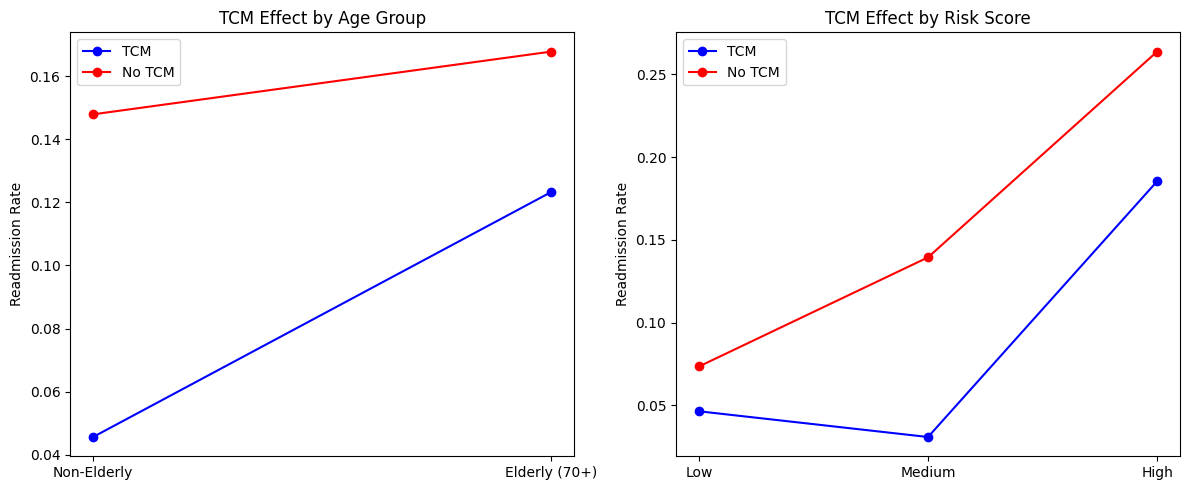

In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TCM × Elderly
elderly_labels = ['Non-Elderly', 'Elderly (70+)']
tcm = [df[(df['TCM_7d']==1) & (df['Elderly']==i)]['30DayReadmissionFlag'].mean() for i in [0,1]]
no_tcm = [df[(df['TCM_7d']==0) & (df['Elderly']==i)]['30DayReadmissionFlag'].mean() for i in [0,1]]

axes[0].plot(elderly_labels, tcm, marker='o', label='TCM', color='blue')
axes[0].plot(elderly_labels, no_tcm, marker='o', label='No TCM', color='red')
axes[0].set_title('TCM Effect by Age Group')
axes[0].set_ylabel('Readmission Rate')
axes[0].legend()

# TCM × Risk Score
df['RiskTertile'] = pd.qcut(df['ReadmissionRiskValue'], q=3, labels=['Low', 'Medium', 'High'])
risk_labels = ['Low', 'Medium', 'High']
tcm_r = [df[(df['TCM_7d']==1) & (df['RiskTertile']==g)]['30DayReadmissionFlag'].mean() for g in risk_labels]
no_tcm_r = [df[(df['TCM_7d']==0) & (df['RiskTertile']==g)]['30DayReadmissionFlag'].mean() for g in risk_labels]

axes[1].plot(risk_labels, tcm_r, marker='o', label='TCM', color='blue')
axes[1].plot(risk_labels, no_tcm_r, marker='o', label='No TCM', color='red')
axes[1].set_title('TCM Effect by Risk Score')
axes[1].set_ylabel('Readmission Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

## Logit Model. Interaction terms for Interventions

In [65]:
import statsmodels.api as sm

# 1. Create the specific interaction terms for Intervention 1 (TCM)
df['TCM_x_Cluster1'] = df['AnchorStayTOCConsult'] * df['cluster_1']
df['TCM_x_Cluster2'] = df['AnchorStayTOCConsult'] * df['cluster_2']

# 2. Create the specific interaction terms for Intervention 2 (TOC Consult)
df['TOC_x_Cluster1'] = df['AnchorStayMedsPriorToDC'] * df['cluster_1']
df['TOC_x_Cluster2'] = df['AnchorStayMedsPriorToDC'] * df['cluster_2']

# 3. Define the full unified model
prof_vars = [
    # Main Interventions
    'AnchorStayTOCConsult',
    'AnchorStayMedsPriorToDC',

    # Main Clusters
    'cluster_1',
    'cluster_2',

    # TCM Interactions
    'TCM_x_Cluster1',
    'TCM_x_Cluster2',

    # TOC Consult Interactions
    'TOC_x_Cluster1',
    'TOC_x_Cluster2',

    # Clinical Covariates (Controls)
    'ReadmissionRiskValue',
    'AgeGroup'
]

# Add any MDCs you want to control for
mdc_cols = [col for col in df.columns if col.startswith('MDC_')]
prof_vars = prof_vars + mdc_cols

# 4. Fit the model
data = df[['30DayReadmissionFlag'] + prof_vars].dropna()
y = data['30DayReadmissionFlag'].astype(float)
X = sm.add_constant(data[prof_vars].astype(float))

# Using HC1 robust standard errors again
prof_model = sm.Logit(y, X).fit(cov_type='HC1')
print(prof_model.summary())

         Current function value: 0.391018
         Iterations: 35
                            Logit Regression Results                            
Dep. Variable:     30DayReadmissionFlag   No. Observations:                 5270
Model:                            Logit   Df Residuals:                     5252
Method:                             MLE   Df Model:                           17
Date:                  Wed, 13 May 2026   Pseudo R-squ.:                 0.08103
Time:                          19:24:07   Log-Likelihood:                -2060.7
converged:                        False   LL-Null:                       -2242.4
Covariance Type:                    HC1   LLR p-value:                 8.028e-67
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -3.3433        nan        nan        nan         nan         nan
AnchorStay

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [66]:
# Check the cross-tabs to find the empty buckets causing separation
print(pd.crosstab(df['cluster_1'], [df['AnchorStayMedsPriorToDC'], df['30DayReadmissionFlag']]))
print("\n")
print(pd.crosstab(df['cluster_2'], [df['AnchorStayMedsPriorToDC'], df['30DayReadmissionFlag']]))

AnchorStayMedsPriorToDC   0        1     
30DayReadmissionFlag      0  1     0    1
cluster_1                                
False                    28  3  4155  683
True                      4  0   301  115


AnchorStayMedsPriorToDC   0        1     
30DayReadmissionFlag      0  1     0    1
cluster_2                                
False                    28  3  3918  694
True                      4  0   538  104


In [67]:
import statsmodels.api as sm

# 1. Create interactions for Intervention 1: TCM_7d
df['TCM_x_Cluster1'] = df['TCM_7d'] * df['cluster_1']
df['TCM_x_Cluster2'] = df['TCM_7d'] * df['cluster_2']

# 2. Create interactions for Intervention 2: AnchorStayMedsPriorToDC
df['TOC_Consult_x_Cluster1'] = df['AnchorStayTOCConsult'] * df['cluster_1']
df['TOC_Consult_x_Cluster2'] = df['AnchorStayTOCConsult'] * df['cluster_2']

# 3. Grab MDC columns and DROP ONE to avoid the Dummy Variable Trap (NaNs)
mdc_cols = [col for col in df.columns if col.startswith('MDC_')]
if 'MDC_Sepsis' in mdc_cols:
    mdc_cols.remove('MDC_Sepsis') # Dropping Sepsis to serve as the baseline

# 4. Define the full unified model
prof_vars = [
    # Main Interventions
    'TCM_7d',
    'AnchorStayTOCConsult',

    # Main Clusters
    'cluster_1',
    'cluster_2',

    # TCM Interactions
    'TCM_x_Cluster1',
    'TCM_x_Cluster2',

    # TOC Consult Interactions
    'TOC_Consult_x_Cluster1',
    'TOC_Consult_x_Cluster2',

    # Clinical Covariates (Controls)
    #'ReadmissionRiskValue',
    'AgeGroup'
] + mdc_cols

# 5. Fit the model
data = df[['30DayReadmissionFlag'] + prof_vars].dropna()
y = data['30DayReadmissionFlag'].astype(float)
X = sm.add_constant(data[prof_vars].astype(float))

# Using HC1 robust standard errors
final_model = sm.Logit(y, X).fit(cov_type='HC1')
print(final_model.summary())

Optimization terminated successfully.
         Current function value: 0.404546
         Iterations 7
                            Logit Regression Results                            
Dep. Variable:     30DayReadmissionFlag   No. Observations:                 5289
Model:                            Logit   Df Residuals:                     5272
Method:                             MLE   Df Model:                           16
Date:                  Wed, 13 May 2026   Pseudo R-squ.:                 0.04860
Time:                          19:24:08   Log-Likelihood:                -2139.6
converged:                         True   LL-Null:                       -2248.9
Covariance Type:                    HC1   LLR p-value:                 1.354e-37
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2.4582      0.165    -14.898      0.000  

### **Report Findings: Prevalence, Comparisons, CI, Sensitivity, and Crosstabs**

In [68]:
# 1. Treatment prevalence table (% receiving each intervention, by readmission status)
print("--- Treatment Prevalence by Readmission Status ---")
interventions = ['AnchorStayMedsPriorToDC', 'AnchorStayTOCConsult', 'TCM_7d']
prev_table = df.groupby('30DayReadmissionFlag')[interventions].mean() * 100
display(prev_table.round(2).astype(str) + '%')

--- Treatment Prevalence by Readmission Status ---


,AnchorStayMedsPriorToDC,AnchorStayTOCConsult,TCM_7d
30DayReadmissionFlag,,,
0,99.29%,31.68%,11.76%
1,99.63%,24.09%,6.12%


In [69]:
# 2. Treated vs. untreated comparison per intervention (SMD/mean tables)
print("--- Treated vs Untreated Comparison (Mean Risk & SDOH Score) ---")
for intv in interventions:
    print(f"\nIntervention: {intv}")
    treated = df[df[intv] == 1]
    untreated = df[df[intv] == 0]

    t_risk = treated['ReadmissionRiskValue'].mean()
    u_risk = untreated['ReadmissionRiskValue'].mean()
    t_sdoh = treated['SDOH Score'].mean()
    u_sdoh = untreated['SDOH Score'].mean()

    print(f"  Treated   (N={len(treated)}) - Risk: {t_risk:.2f}, SDOH: {t_sdoh:.2f}")
    print(f"  Untreated (N={len(untreated)}) - Risk: {u_risk:.2f}, SDOH: {u_sdoh:.2f}")

--- Treated vs Untreated Comparison (Mean Risk & SDOH Score) ---

Intervention: AnchorStayMedsPriorToDC
  Treated   (N=5254) - Risk: 17.93, SDOH: 3.18
  Untreated (N=35) - Risk: 18.69, SDOH: 3.71

Intervention: AnchorStayTOCConsult
  Treated   (N=1615) - Risk: 15.30, SDOH: 3.11
  Untreated (N=3674) - Risk: 19.10, SDOH: 3.22

Intervention: TCM_7d
  Treated   (N=577) - Risk: 16.27, SDOH: 3.32
  Untreated (N=4712) - Risk: 18.14, SDOH: 3.17


In [70]:
# 3. Overall readmission rate 95% CI
import statsmodels.stats.proportion as proportion

readmits = df['30DayReadmissionFlag'].sum()
total = len(df)
ci_low, ci_high = proportion.proportion_confint(readmits, total, alpha=0.05, method='normal')

print(f"Overall Readmission Rate: {(readmits/total)*100:.2f}%")
print(f"95% Confidence Interval: {ci_low*100:.2f}% - {ci_high*100:.2f}%")

Overall Readmission Rate: 15.14%
95% Confidence Interval: 14.18% - 16.11%


In [71]:
# 4. Time window sensitivity table (TCM_7d vs TCM_10d vs TCM_14d regression side-by-side)
import statsmodels.api as sm
import numpy as np

print("--- Time Window Sensitivity (TCM_7d, TCM_10d, TCM_14d) ---")
base_cols = ['ReadmissionRiskValue', 'AgeGroup', 'SVI_z']

results_list = []
for tcm_var in ['TCM_7d', 'TCM_10d', 'TCM_14d']:
    model_vars = [tcm_var] + base_cols
    data = df[['30DayReadmissionFlag'] + model_vars].dropna()

    X = sm.add_constant(data[model_vars].astype(float))
    y = data['30DayReadmissionFlag'].astype(float)

    res = sm.Logit(y, X).fit(disp=False, cov_type='HC1')

    results_list.append({
        'Model Window': tcm_var,
        'Odds Ratio': round(np.exp(res.params[tcm_var]), 3),
        'p-value': round(res.pvalues[tcm_var], 3),
        'Pseudo R-squ': round(res.prsquared, 4)
    })

display(pd.DataFrame(results_list))

--- Time Window Sensitivity (TCM_7d, TCM_10d, TCM_14d) ---


,Model Window,Odds Ratio,p-value,Pseudo R-squ
0,TCM_7d,0.526,0.0,0.0872
1,TCM_10d,0.512,0.0,0.0895
2,TCM_14d,0.534,0.0,0.0903


In [72]:
# 5. TOC Consult prevalence by subgroup (MDC, age, SDOH cluster crosstab)
print("--- TOC Consult Prevalence by Subgroup ---")

print("\nBy Age Group:")
age_prev = (df.groupby('AgeGroup')['AnchorStayTOCConsult'].mean() * 100).round(2)
display(age_prev.astype(str) + '%')

print("\nBy SDOH Cluster:")
cluster_prev = (df.groupby('sdoh_cluster')['AnchorStayTOCConsult'].mean() * 100).round(2)
display(cluster_prev.astype(str) + '%')

print("\nBy MDC Category:")
mdc_cols = [c for c in df.columns if c.startswith('MDC_')]
mdc_prev = {mdc.replace('MDC_', ''): df[df[mdc]==1]['AnchorStayTOCConsult'].mean() * 100 for mdc in mdc_cols}
mdc_prev_series = pd.Series(mdc_prev).sort_values(ascending=False).round(2)
display(mdc_prev_series.astype(str) + '%')

--- TOC Consult Prevalence by Subgroup ---

By Age Group:


,AnchorStayTOCConsult
AgeGroup,
1,17.27%
2,32.2%
3,41.52%
4,34.06%
5,30.23%
6,26.14%



By SDOH Cluster:


,AnchorStayTOCConsult
sdoh_cluster,
0,30.81%
1,32.62%
2,27.4%



By MDC Category:


,0
Stroke,74.89%
AMI,50.82%
HF,26.36%
COPD,24.07%
CABG,18.6%
Sepsis,11.96%
PN,11.78%
HipKnee,9.65%
